<a href="https://www.kaggle.com/code/allasamoilenko/hw-9-samoilenko?scriptVersionId=229100194" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from lightgbm import LGBMRegressor

df = pd.read_csv("/kaggle/input/small-nice-data-dota2/small_nice_data.csv",
                 index_col=0)

df.head()

,time,radiant_roshankill,radiant_Δroshankill,dire_roshankill,dire_Δroshankill,good_tower1,good_tower2,good_tower3,good_melee,good_range,...,radiant_buyback,dire_buyback,radiant_Δrunes,dire_Δrunes,radiant_runes,dire_runes,radiant_aegis,dire_aegis,radiantΔaegis,direΔaegis
0,0,0,0,0,0,3,3,3,3,3,...,0,0,1,1,1,1,0,0,0,0
1,60,0,0,0,0,3,3,3,3,3,...,0,0,1,1,2,2,0,0,0,0
2,120,0,0,0,0,3,3,3,3,3,...,0,0,0,0,2,2,0,0,0,0
3,180,0,0,0,0,3,3,3,3,3,...,0,0,0,0,2,2,0,0,0,0
4,240,0,0,0,0,3,3,3,3,3,...,0,0,0,0,2,2,0,0,0,0


In [6]:
df.isnull().values.any()

False

<Axes: >

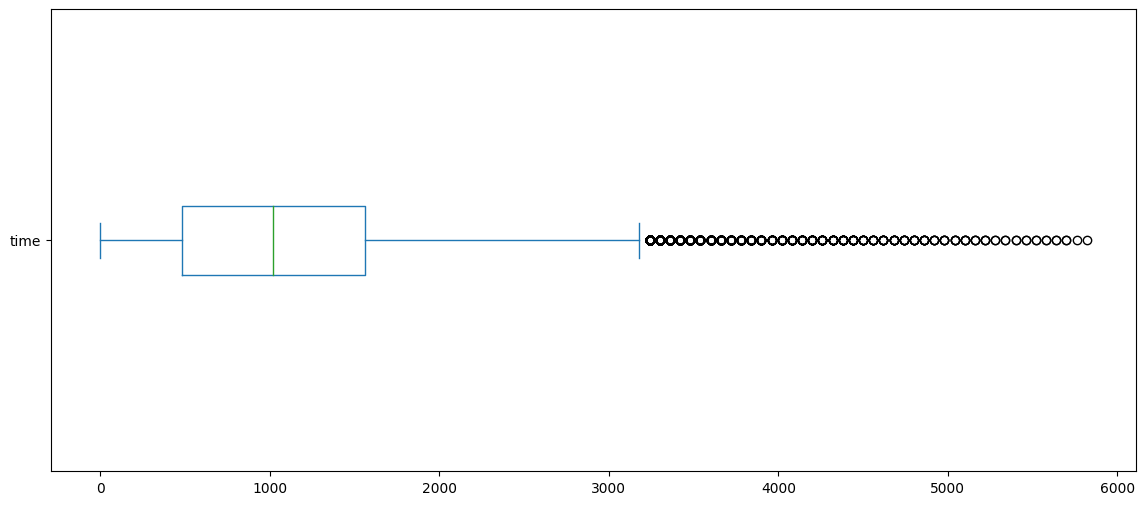

In [7]:
df['time'].plot(kind='box', vert = False, figsize=(14,6))

In [8]:
X = df.drop('time', axis=1)
y = df['time']

In [24]:
y

0            0
1           60
2          120
3          180
4          240
          ... 
164738    1200
164739    1260
164740    1320
164741    1380
164742    1440
Name: time, Length: 164300, dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LGBMRegressor())
])

In [18]:
pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8357
[LightGBM] [Info] Number of data points in the train set: 131440, number of used features: 82
[LightGBM] [Info] Start training from score 1072.303256


Pipeline(steps=[('imputer', SimpleImputer()), ('model', LGBMRegressor())])

In [19]:
y_pred = pipeline.predict(X_test)

In [22]:
mse = mean_squared_error(y_test, y_pred)
mse

1696.4864517470037